# Лабораторная работа 9: Методы обучения без учителя.

Цель лабораторной работы: изучение методов кластеризации и снижения размерности.

Задание:

    Выберите набор данных (датасет) для решения задачи обучения без учителя.
    Выберите подмножество признаков датасета для анализа. Например, подмножество признаков может не включать целевой признак. Количество признаков в подмножестве должно быть более двух. Полученный датасет назовем датасетом D1.
    С использованием метода главных компонент проведите для датасета D1 снижение размерности данных до двух. Полученный датасет назовем датасетом D2.
    С использованием алгоритма t-SNE также проведите для датасета D1 снижение размерности данных до двух. Полученный датасет назовем датасетом D3.
    Визуализируйте точки датасетов D2 и D3. В каком случае кластеры выделены наиболее явно?
    Для датасетов D1, D2 и D3 проведите кластеризацию с использованием как минимум трех методов кластеризации, рассмотренных в лекции. Оцените качество кластеризации с использованием метрик, рассмотренных в лекции.
    Сделайте выводы о том, какой метод кластеризации и почему оказался лучше для каждого из датасетов.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.datasets import load_wine
from sklearn.metrics import calinski_harabasz_score, silhouette_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target  

# Возьмем 5 ключевых химических параметров
selected_features = [
    "alcohol",
    "malic_acid",
    "ash",
    "total_phenols",
    "flavanoids",
]
D1_raw = X[selected_features]

# Масштабирование признаков (критически важно для PCA и кластеризации)
scaler = StandardScaler()
D1 = scaler.fit_transform(D1_raw)

print(f"Форма датасета D1: {D1.shape}")

Форма датасета D1: (178, 5)


In [3]:
# Снижение размерности (Датасеты D2 и D3)

# Метод главных компонент (PCA) -> D2
pca = PCA(n_components=2, random_state=42)
D2 = pca.fit_transform(D1)

# Алгоритм t-SNE -> D3
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
D3 = tsne.fit_transform(D1)

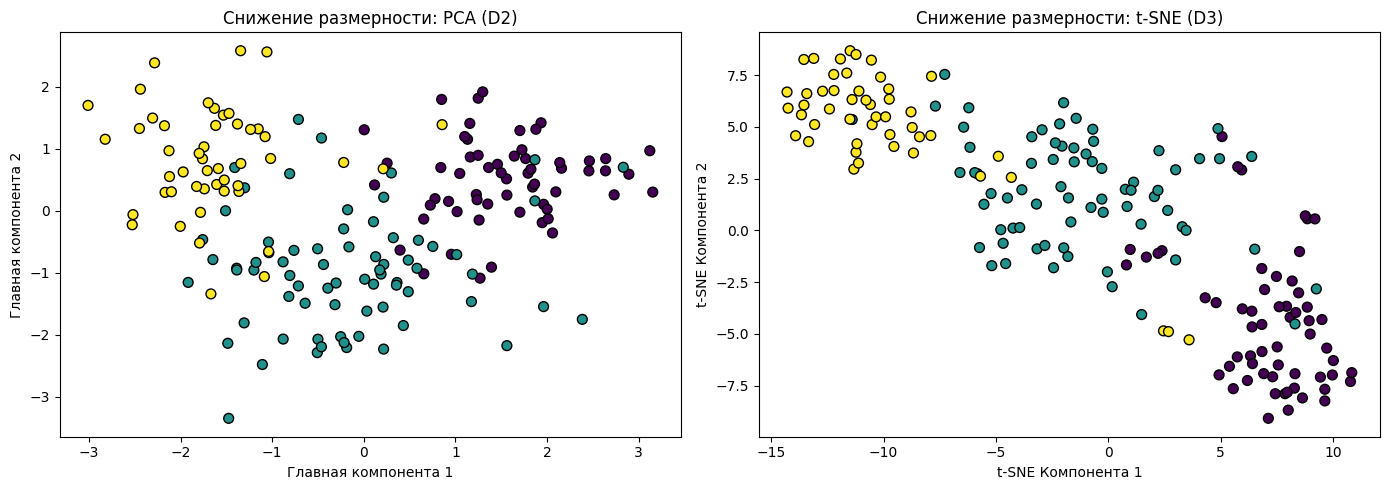

In [4]:
# Визуализация D2 и D3
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График PCA
axes[0].scatter(D2[:, 0], D2[:, 1], c=y, cmap="viridis", edgecolor="k", s=50)
axes[0].set_title("Снижение размерности: PCA (D2)")
axes[0].set_xlabel("Главная компонента 1")
axes[0].set_ylabel("Главная компонента 2")

# График t-SNE
axes[1].scatter(D3[:, 0], D3[:, 1], c=y, cmap="viridis", edgecolor="k", s=50)
axes[1].set_title("Снижение размерности: t-SNE (D3)")
axes[1].set_xlabel("t-SNE Компонента 1")
axes[1].set_ylabel("t-SNE Компонента 2")

plt.tight_layout()
plt.show()

In [5]:
# Кластеризация и оценка качества
# Инициализируем три метода кластеризации
# (Предполагаем 3 кластера для KMeans и Agglomerative, так как в wine 3 класса)
models = {
    "K-Means": KMeans(n_clusters=3, random_state=42, n_init=10),
    "Hierarchical": AgglomerativeClustering(n_clusters=3),
    "DBSCAN": DBSCAN(eps=0.5, min_samples=4),  # Параметры подбираются базово
}

datasets = {"D1 (Исходный подвыборка)": D1, "D2 (PCA)": D2, "D3 (t-SNE)": D3}

results = []

for ds_name, dataset in datasets.items():
    for model_name, model in models.items():
        # Обучение и получение меток
        labels = model.fit_predict(dataset)

        # Метрики можно считать, только если выделилось более 1 кластера
        # (Актуально для DBSCAN, который может все пометить как шум (-1) или найти 1 кластер)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        if n_clusters > 1:
            sil = silhouette_score(dataset, labels)
            ch = calinski_harabasz_score(dataset, labels)
        else:
            sil, ch = np.nan, np.nan

        results.append(
            {
                "Датасет": ds_name,
                "Метод кластеризации": model_name,
                "Кол-во кластеров": len(set(labels)),
                "Силуэт (Silhouette)": sil,
                "Калински-Харабас (CH)": ch,
            }
        )

# Вывод результатов в виде таблицы DataFrame
df_results = pd.DataFrame(results)
print("\nСводная таблица результатов:")
print(df_results.to_string(index=False))


Сводная таблица результатов:
                 Датасет Метод кластеризации  Кол-во кластеров  Силуэт (Silhouette)  Калински-Харабас (CH)
D1 (Исходный подвыборка)             K-Means                 3             0.331120              93.647373
D1 (Исходный подвыборка)        Hierarchical                 3             0.306926              82.081351
D1 (Исходный подвыборка)              DBSCAN                 4            -0.099497               4.780419
                D2 (PCA)             K-Means                 3             0.488717             230.597180
                D2 (PCA)        Hierarchical                 3             0.477184             218.027563
                D2 (PCA)              DBSCAN                 2                  NaN                    NaN
              D3 (t-SNE)             K-Means                 3             0.558143             528.881957
              D3 (t-SNE)        Hierarchical                 3             0.544634             493.972624
       